In [109]:

# from sklearn.datasets import fetch_openml

# higgs_data = fetch_openml( name = 'higgs' , version=1 , as_frame=True)

# df = higgs_data.frame


import pandas as pd

df = pd.read_csv( 'higgs.csv')

df = df.dropna()

#! La prima colonna è la mia colonna delle y, l'obiettivo è stimare al meglio possibile quella
y_df = df['class']
x_df = df.drop(columns=['class'], inplace=False)
display(df)

,class,lepton_pT,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet1pt,jet1eta,jet1phi,jet1b-tag,...,jet4eta,jet4phi,jet4b-tag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
0,1,0.907542,0.329147,0.359412,1.497970,-0.313010,1.095531,-0.557525,-1.588230,2.173076,...,-1.138930,-0.000819,0.000000,0.302220,0.833048,0.985700,0.978098,0.779732,0.992356,0.798343
1,1,0.798835,1.470639,-1.635975,0.453773,0.425629,1.104875,1.282322,1.381664,0.000000,...,1.128848,0.900461,0.000000,0.909753,1.108330,0.985692,0.951331,0.803252,0.865924,0.780118
2,0,1.344385,-0.876626,0.935913,1.992050,0.882454,1.786066,-1.646778,-0.942383,0.000000,...,-0.678379,-1.360356,0.000000,0.946652,1.028704,0.998656,0.728281,0.869200,1.026736,0.957904
3,1,1.105009,0.321356,1.522401,0.882808,-1.205349,0.681466,-1.070464,-0.921871,0.000000,...,-0.373566,0.113041,0.000000,0.755856,1.361057,0.986610,0.838085,1.133295,0.872245,0.808487
4,0,1.595839,-0.607811,0.007075,1.818450,-0.111906,0.847550,-0.566437,1.581239,2.173076,...,-0.654227,-1.274345,3.101961,0.823761,0.938191,0.971758,0.789176,0.430553,0.961357,0.957818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98044,0,2.786130,-0.679884,-1.673151,0.854033,1.020573,0.844252,-0.323831,-0.132437,0.000000,...,-0.807466,1.054172,0.000000,0.931880,0.880436,1.399047,1.041965,0.875924,1.056742,1.383591
98045,1,0.908091,-0.825006,-0.830871,0.736298,1.512713,0.881811,-0.363440,0.006813,1.086538,...,-0.187013,0.716785,0.000000,1.317681,1.010795,0.985962,0.957878,1.454672,0.903937,0.786069
98046,0,2.512898,0.530759,-1.470626,1.641798,1.613386,0.934027,1.521958,-0.049836,0.000000,...,0.053673,-0.386483,0.000000,0.774413,0.745263,0.997088,1.392387,0.864681,1.179783,1.086167
98047,0,0.903699,0.261943,-0.429149,1.892855,0.313687,0.493396,-1.494282,-1.458506,0.000000,...,-0.283621,1.110772,3.101961,0.527038,0.607263,1.125286,0.634106,0.115543,0.425828,0.692506


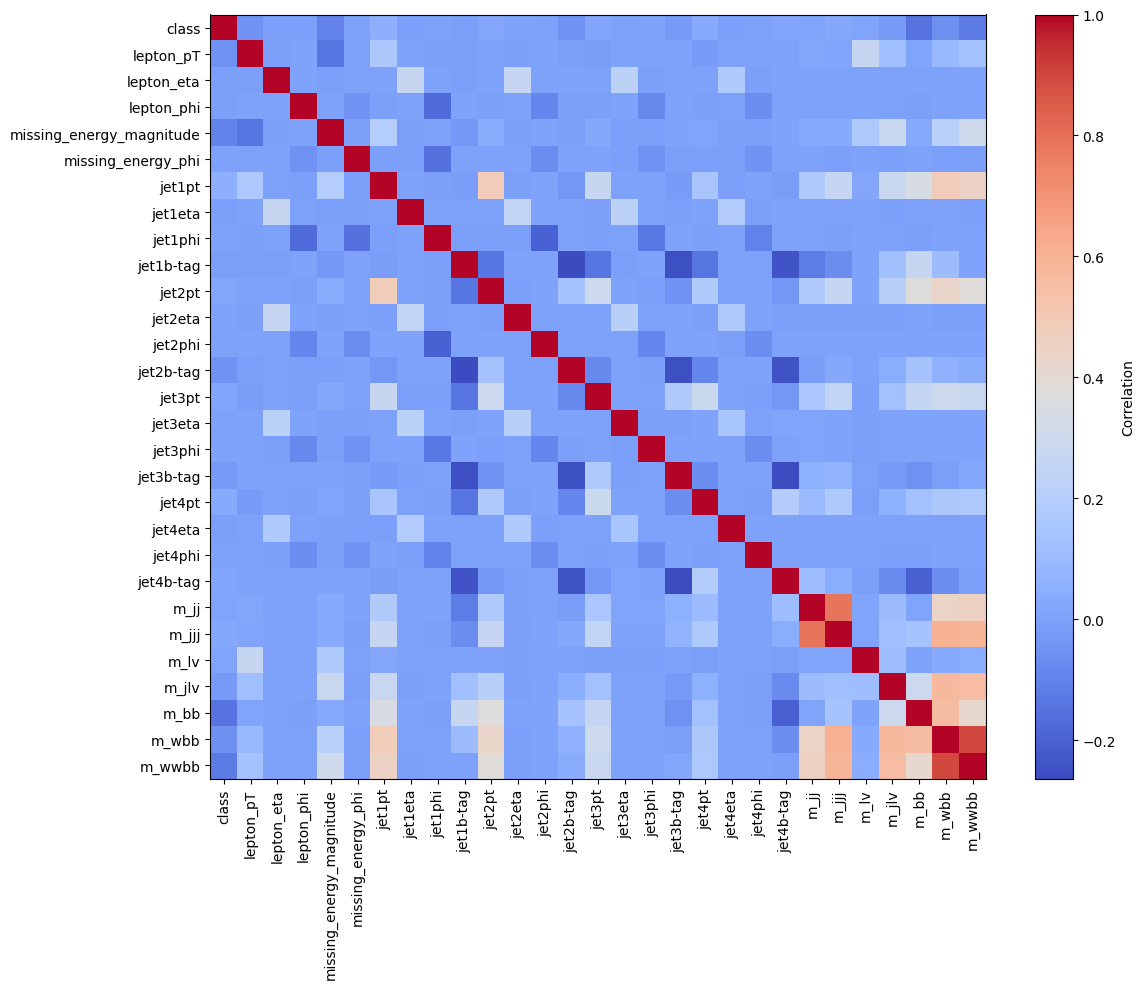

In [110]:
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.tight_layout()
plt.show()

# PCA

In [111]:
from sklearn.decomposition import PCA


pca = PCA()
data_pca = pca.fit_transform(x_df.to_numpy())
print(x_df.shape)
print(data_pca.shape)

predicted_dataset = pca.inverse_transform(data_pca)
print(predicted_dataset.shape)



(98049, 28)
(98049, 28)
(98049, 28)


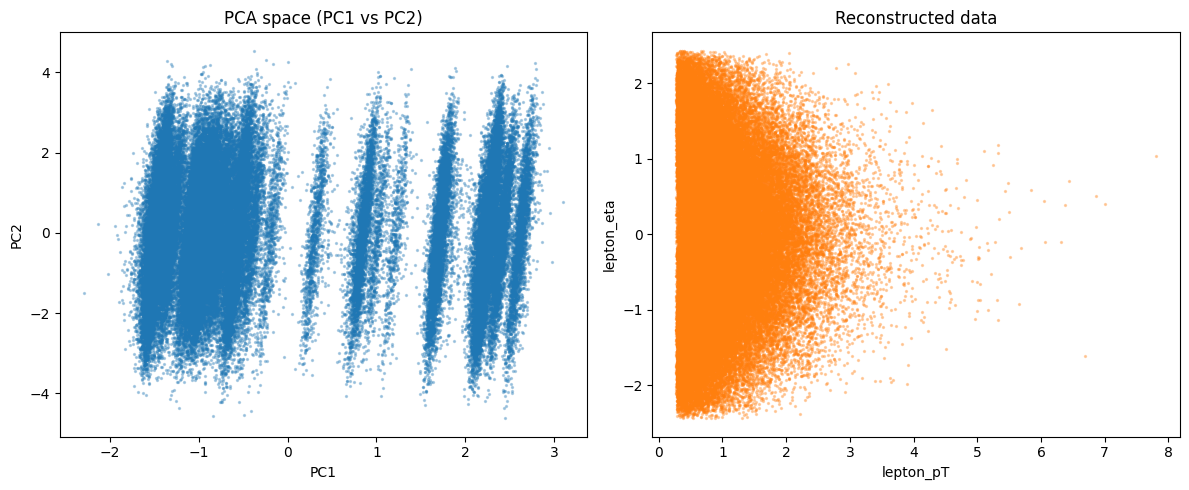

In [112]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(data_pca[:, 0], data_pca[:, 1], s=2, alpha=0.3)
axes[0].set_title("PCA space (PC1 vs PC2)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(predicted_dataset[:, 0], predicted_dataset[:, 1], s=2, alpha=0.3, color="tab:orange")
axes[1].set_title("Reconstructed data")
axes[1].set_xlabel(x_df.columns[0])
axes[1].set_ylabel(x_df.columns[1])

plt.tight_layout()
plt.show()

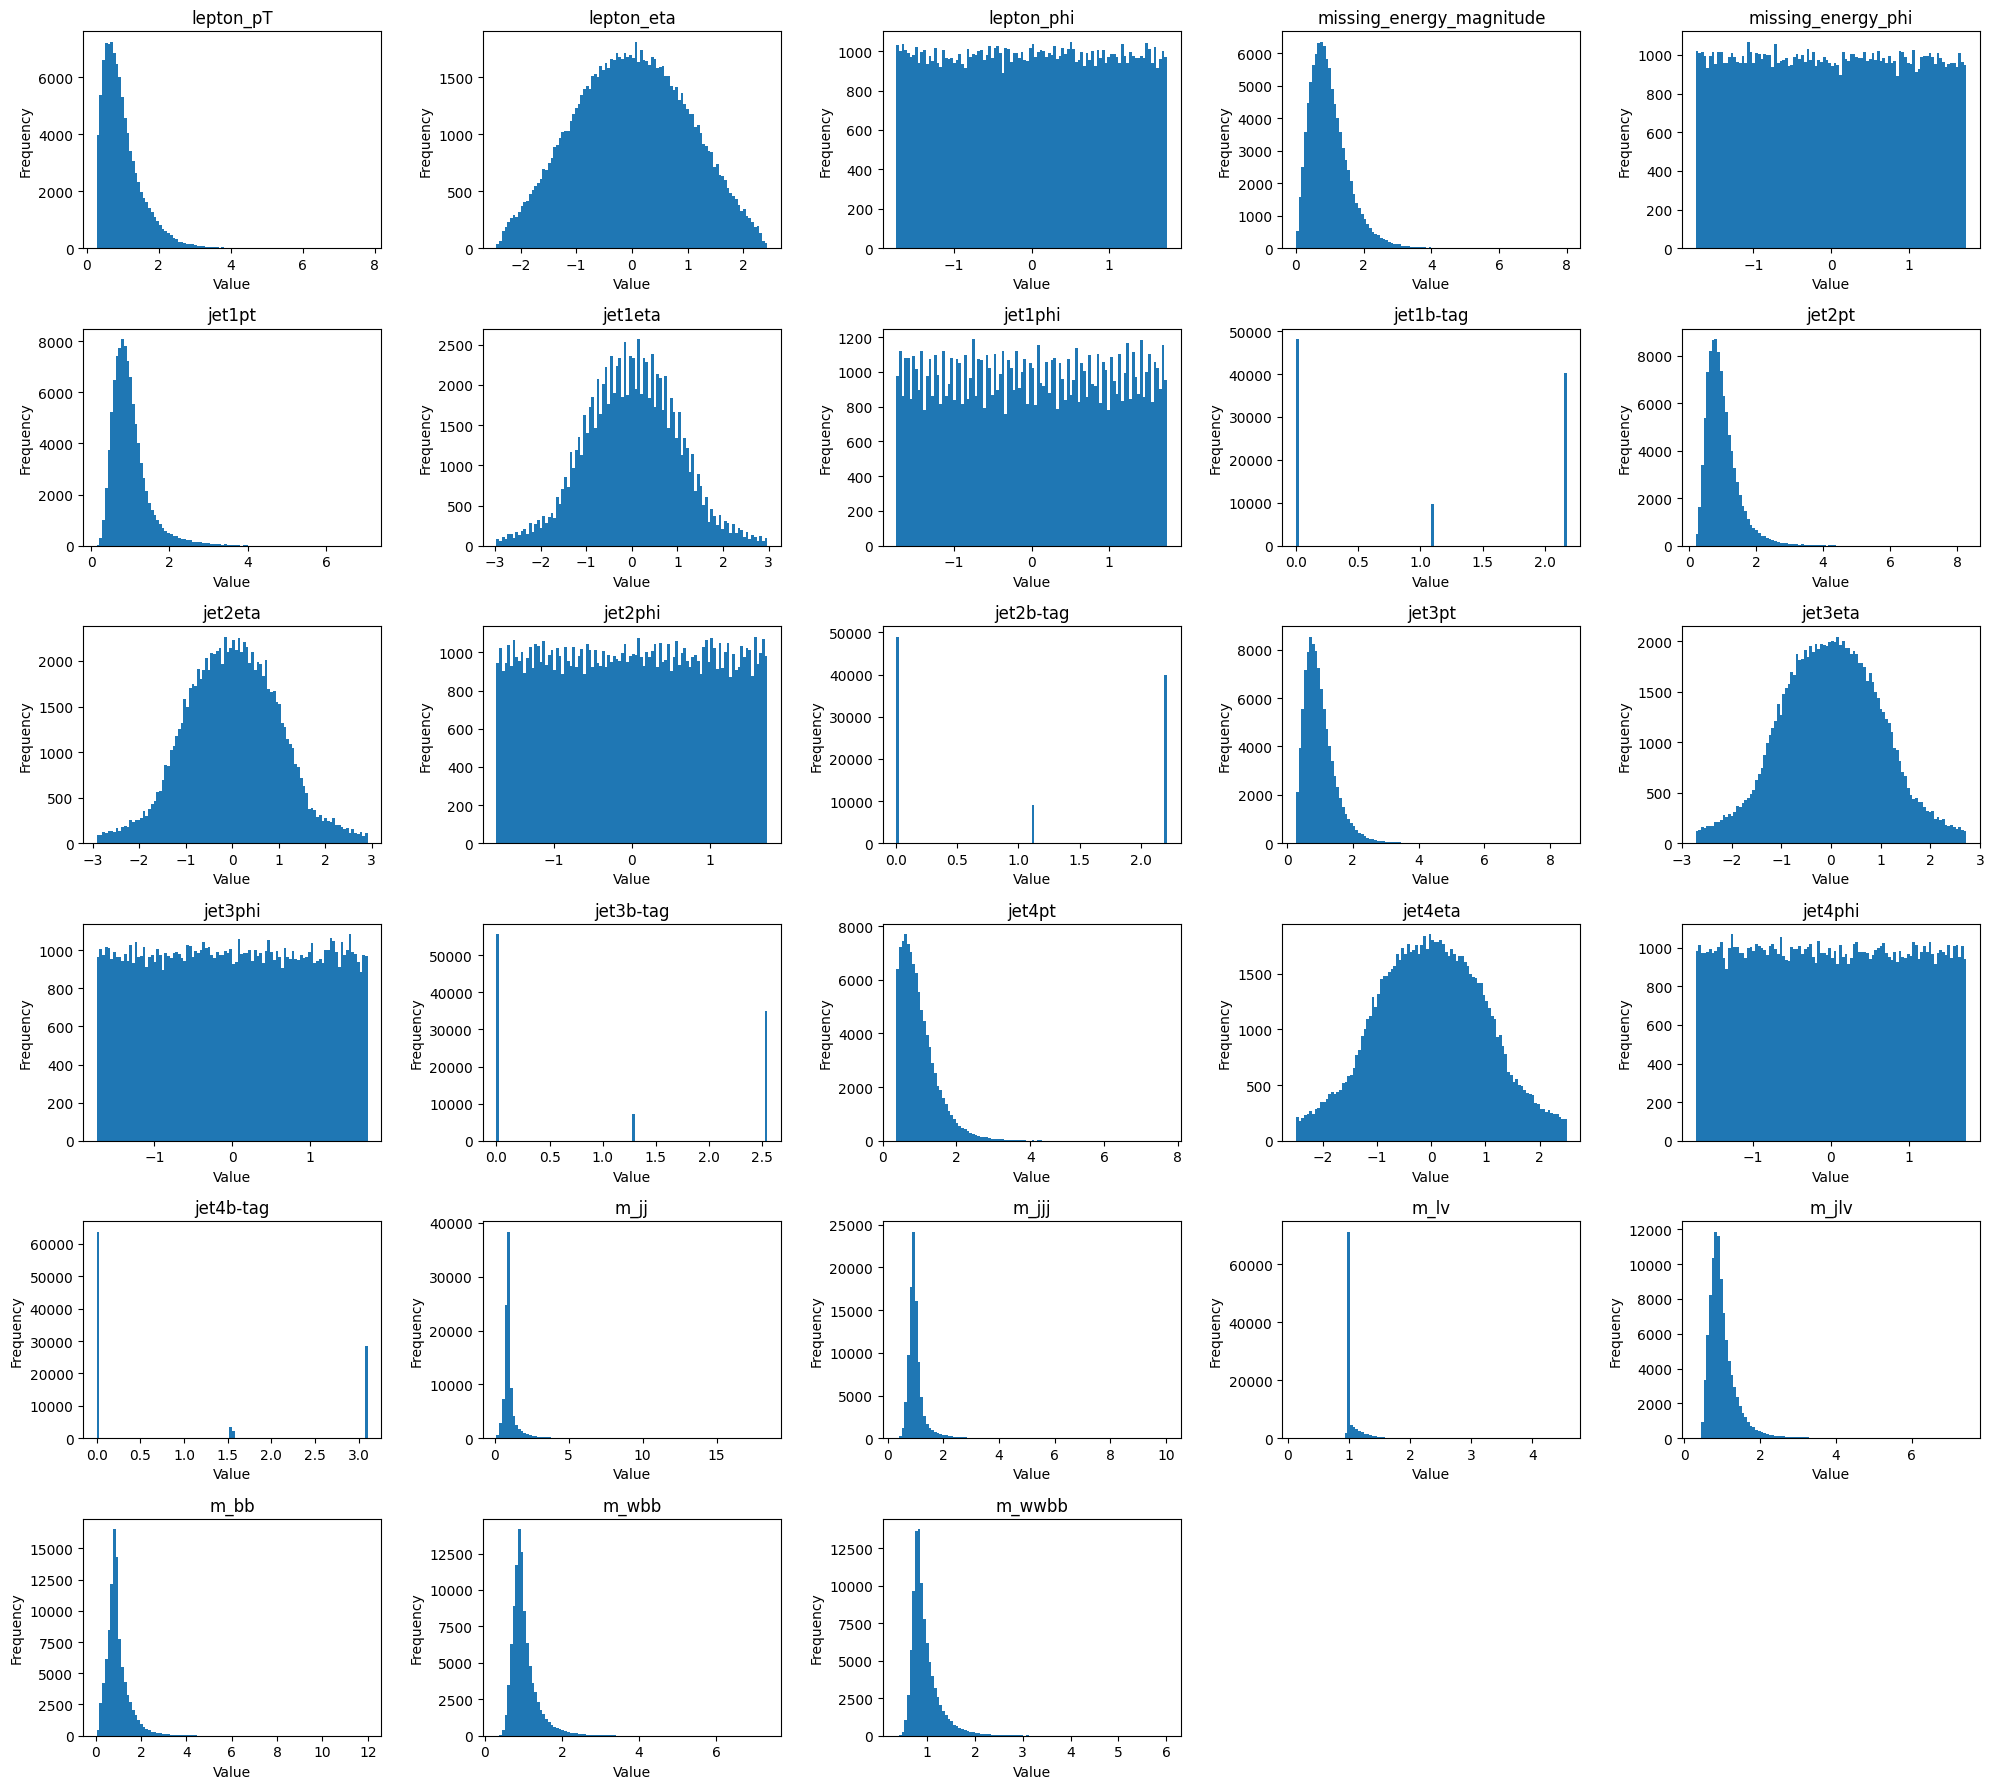

In [113]:
n_features = min(29, predicted_dataset.shape[1])
n_cols = 5
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.ravel()

for i in range(n_features):
    axes[i].hist(predicted_dataset[:, i], bins=100)
    # axes[i].hist(df.to_numpy()[:, i], bins = 100)
    axes[i].set_title(x_df.columns[i])
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

# Hide empty subplots
for j in range(n_features, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

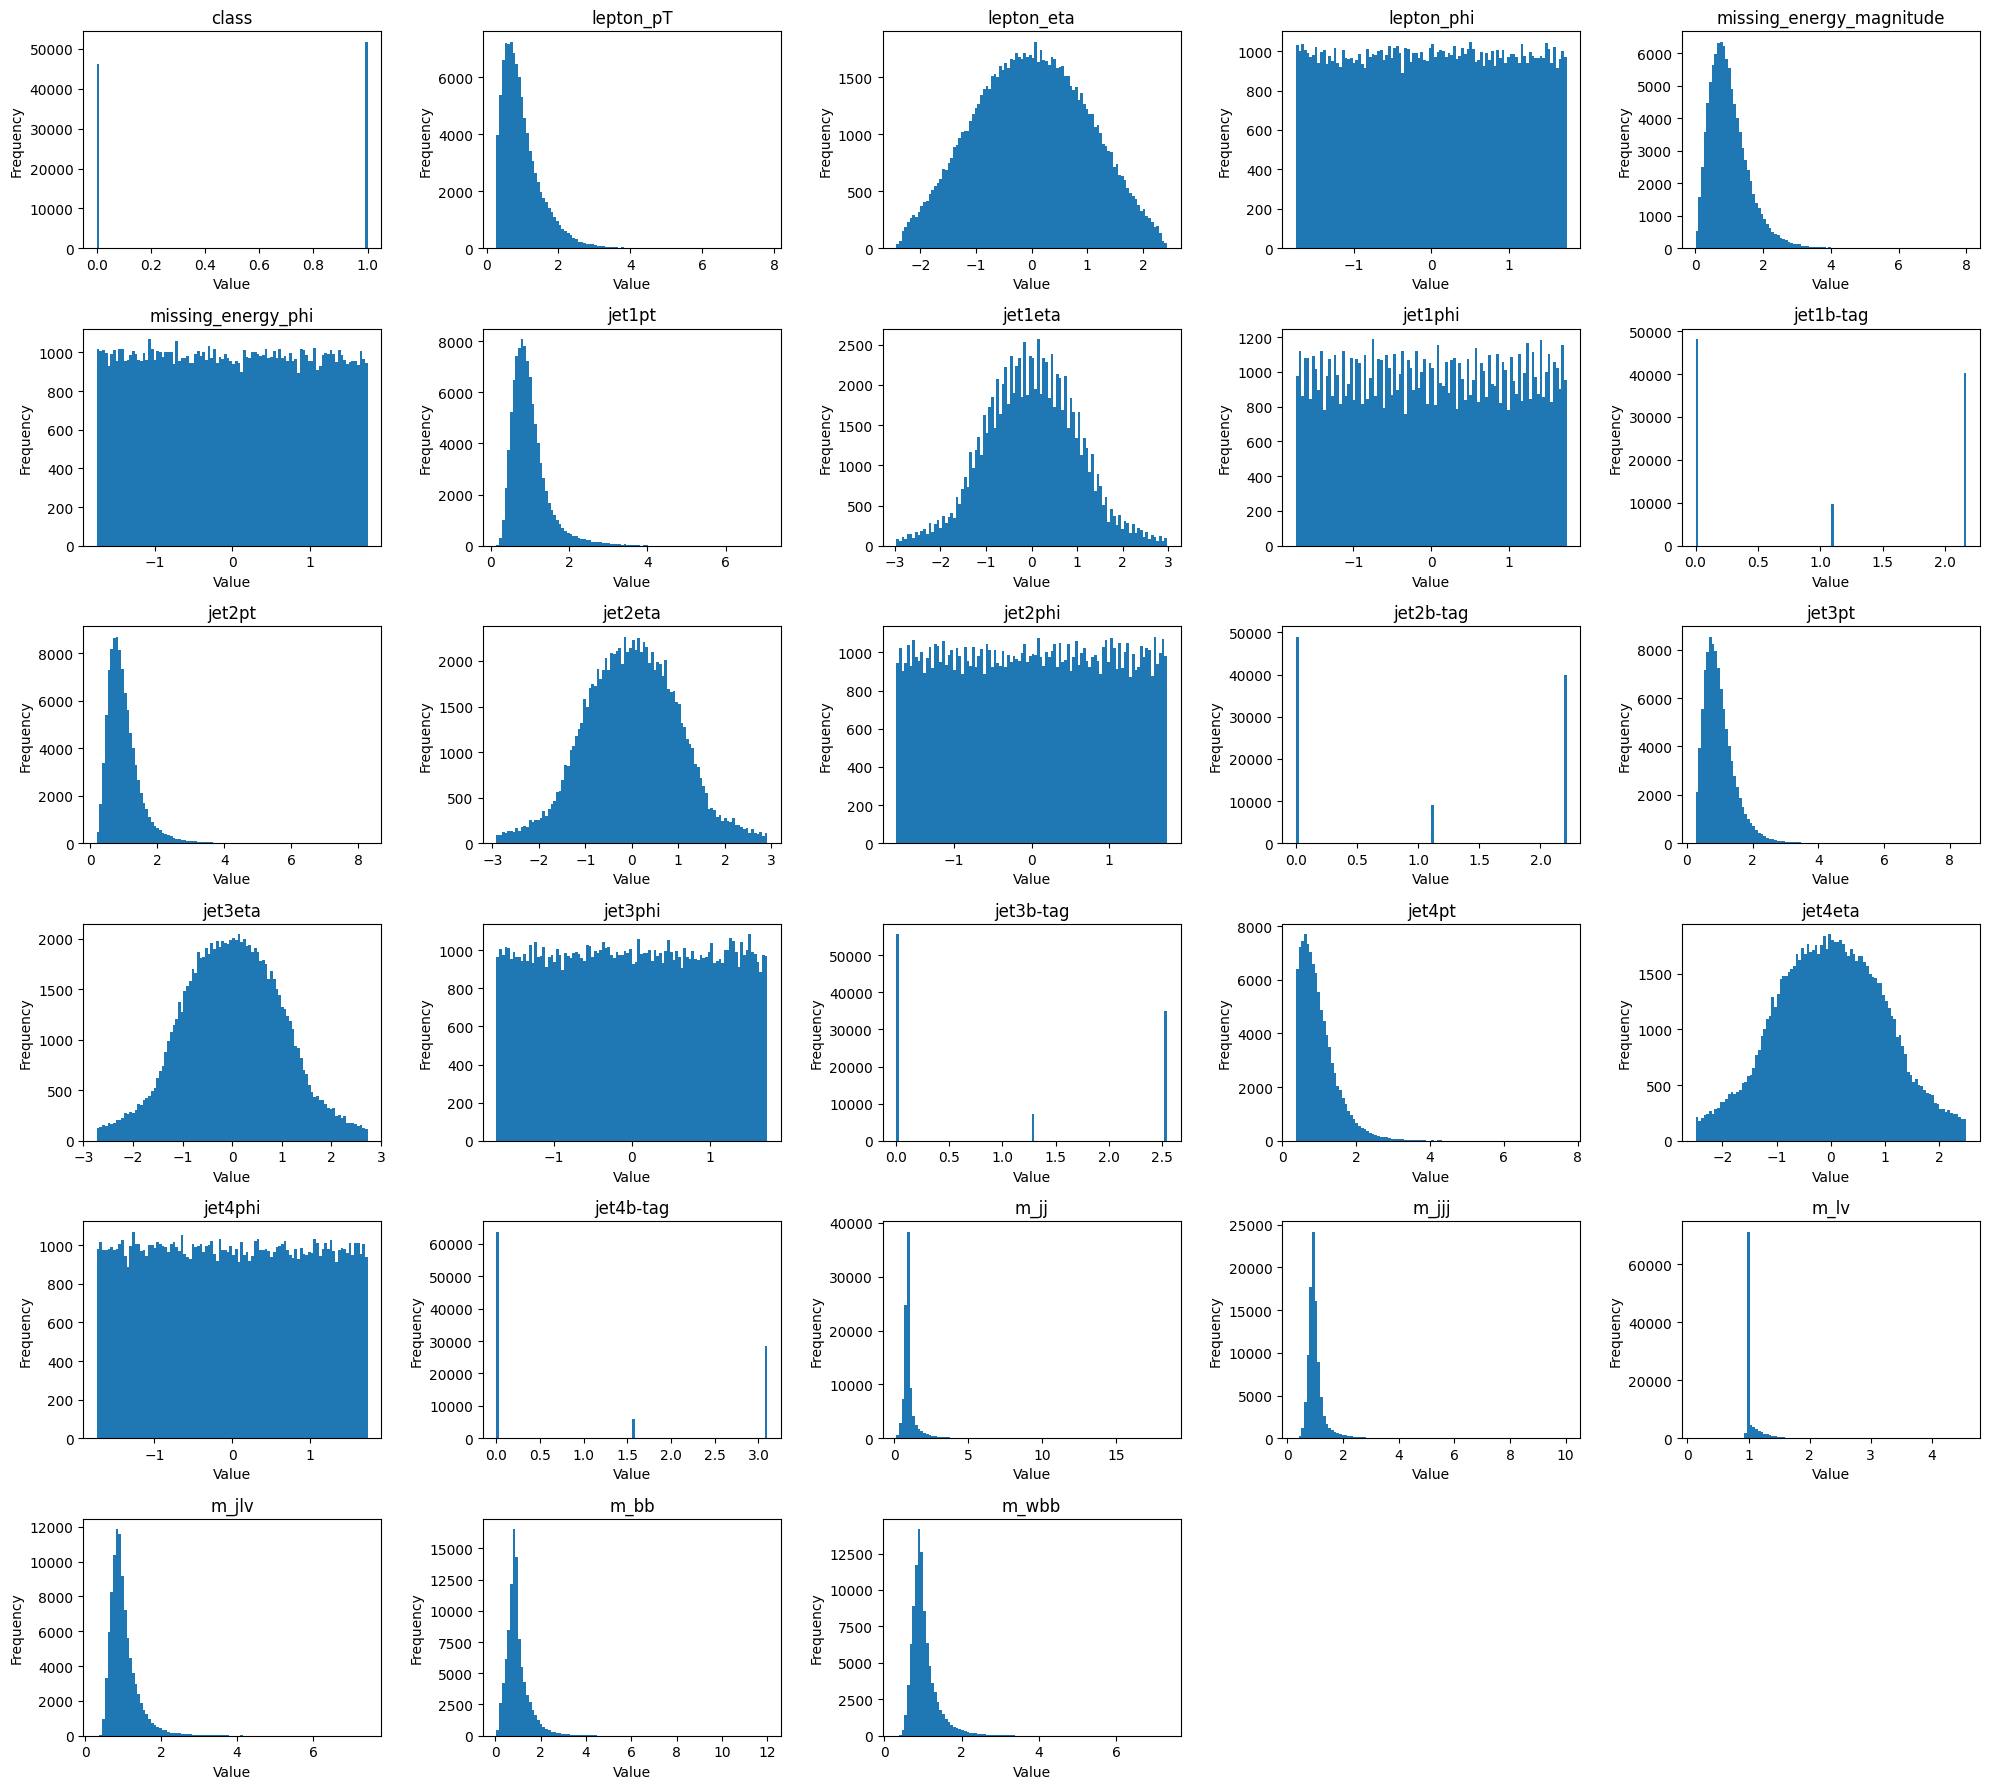

In [114]:
n_features = min(29, predicted_dataset.shape[1])
n_cols = 5
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.ravel()

for i in range(n_features):
    # axes[i].hist(revert_dataset[:, i], bins=100)
    axes[i].hist(df.to_numpy()[:, i], bins = 100)
    axes[i].set_title(df.columns[i])
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

# Hide empty subplots
for j in range(n_features, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

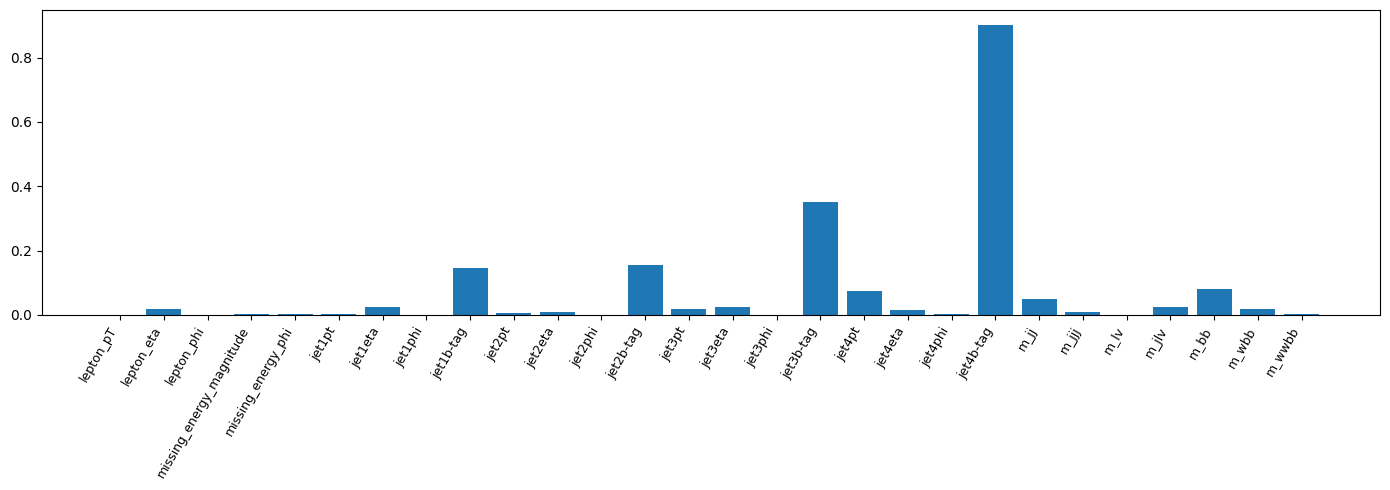

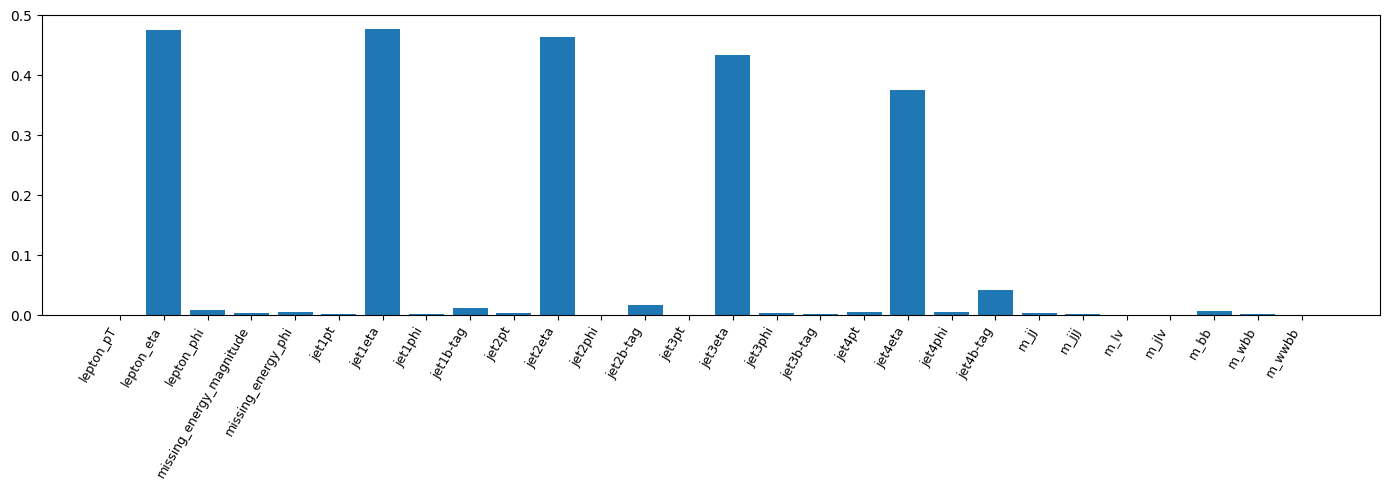

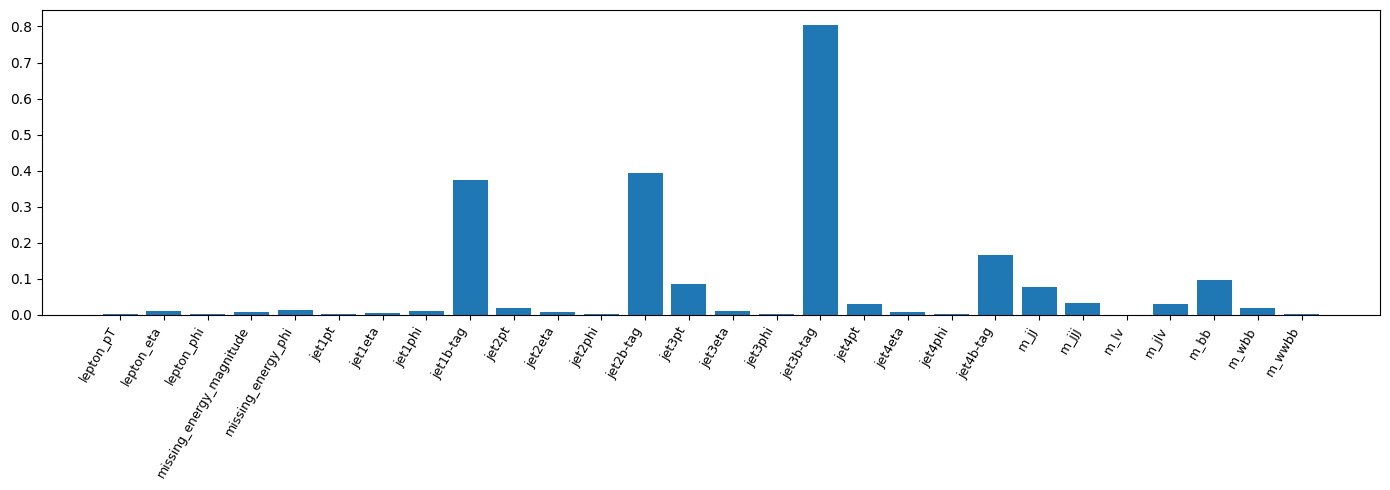

In [115]:
import numpy as np


x = x_df.columns
percents = pca.components_[0]

plt.figure(figsize=(14, 5))
plt.bar(x, abs(percents))
plt.xticks(rotation=60, ha='right', fontsize=9)
plt.tight_layout()

x = x_df.columns
percents = pca.components_[1]

plt.figure(figsize=(14, 5))
plt.bar(x, abs(percents))
plt.xticks(rotation=60, ha='right', fontsize=9)
plt.tight_layout()

x = x_df.columns
percents = pca.components_[2]

plt.figure(figsize=(14, 5))
plt.bar(x, abs(percents))
plt.xticks(rotation=60, ha='right', fontsize=9)
plt.tight_layout()

# Ridge and Lasso

In [116]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.linear_model import Lasso, Ridge

kf = KFold(shuffle=True , random_state=0)
x_dataset = x_df.to_numpy()
y_dataset = y_df.to_numpy()
alpha_range = np.logspace( -5 , 5 , 100)

metric = mean_squared_error

lasso_mse_score = []
ridge_mse_score = []

for alpha in alpha_range:
    mse1 = []
    mse2 = []
    for train_index , test_index in kf.split(x_dataset):
        x_train , x_test = x_dataset[train_index] , x_dataset[test_index]
        y_train , y_test = y_dataset[train_index] , y_dataset[test_index]

        lasso = Lasso(alpha= alpha , max_iter=5000)
        lasso.fit(x_train , y_train)
        y_prediction = lasso.predict(x_test)

        ridge = Ridge( alpha=alpha , max_iter=5000)
        ridge.fit( x_train , y_train)
        y_prediction = ridge.predict(x_test)

        mse1.append(metric(y_test , y_prediction))
        mse2.append(metric(y_test , y_prediction))
    lasso_mse_score.append(np.mean(mse1))
    ridge_mse_score.append(np.mean(mse2))

lasso_top_prediction = np.argmin(lasso_mse_score)
ridge_top_prediction = np.argmin(ridge_mse_score)


best_lasso = Lasso(alpha = alpha_range[lasso_top_prediction] , max_iter=5000)
best_lasso.fit(x_dataset, y_dataset)

best_ridge = Ridge( alpha = alpha_range[ridge_top_prediction] , max_iter=5000)
best_ridge.fit(x_dataset, y_dataset);

<Figure size 1400x500 with 0 Axes>

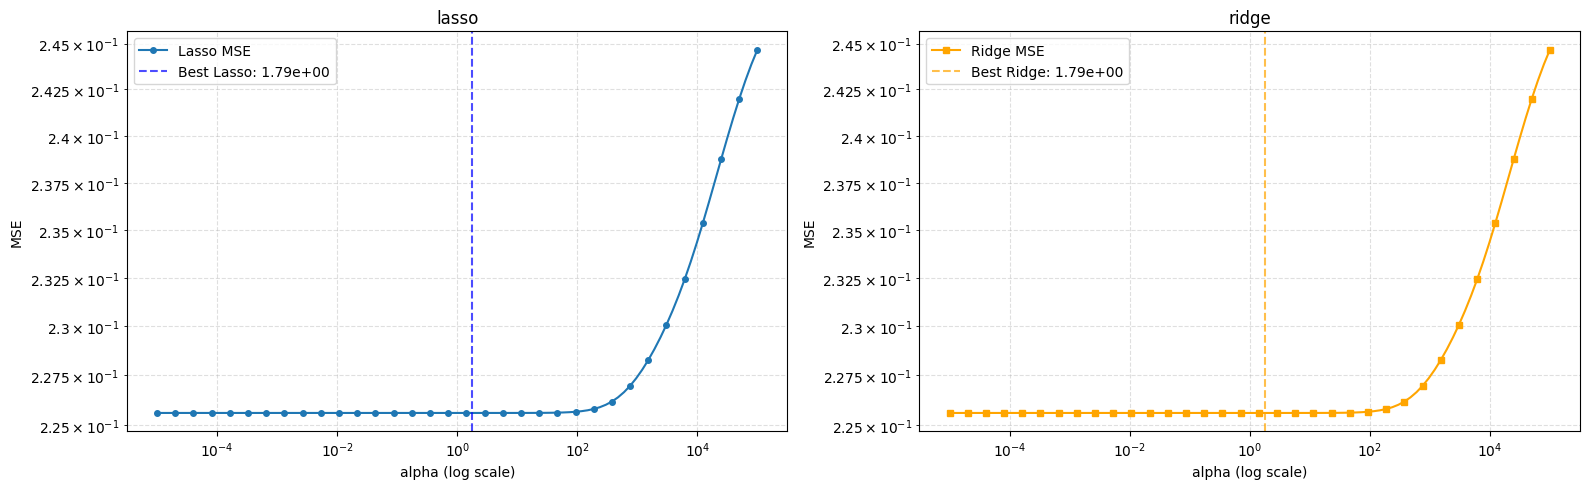

Best Lasso alpha: 1.7886495290574351
Best Ridge alpha: 1.7886495290574351


In [117]:
plt.figure(figsize=(14, 5))
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].loglog(alpha_range, lasso_mse_score, label="Lasso MSE", marker="o", markersize=4, markevery=3)

axes[0].set_xlabel("alpha (log scale)")
axes[0].set_ylabel("MSE")
axes[0].set_title("lasso")
axes[0].grid(True, which="both", ls="--", alpha=0.4)
axes[0].axvline(alpha_range[lasso_top_prediction], color='blue', linestyle='--', alpha=0.7, label=f"Best Lasso: {alpha_range[lasso_top_prediction]:.2e}")
axes[0].legend()

axes[1].loglog(alpha_range, ridge_mse_score, label="Ridge MSE", marker="s", markersize=4, markevery=3 , color = 'orange')
axes[1].set_xlabel("alpha (log scale)")
axes[1].set_ylabel("MSE")
axes[1].set_title("ridge")
axes[1].grid(True, which="both", ls="--", alpha=0.4)
axes[1].axvline(alpha_range[ridge_top_prediction], color='orange', linestyle='--', alpha=0.7, label=f"Best Ridge: {alpha_range[ridge_top_prediction]:.2e}")
axes[1].legend()
plt.legend()
plt.tight_layout()
plt.show()

print("Best Lasso alpha:", alpha_range[np.argmin(lasso_mse_score)])
print("Best Ridge alpha:", alpha_range[np.argmin(ridge_mse_score)])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


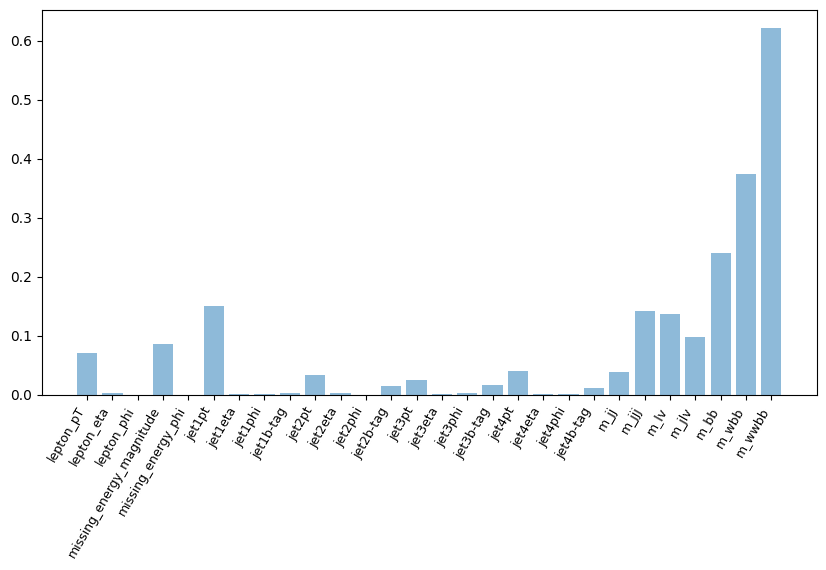

In [118]:
x = x_df.columns
print(best_lasso.coef_)
plt.figure(figsize=(10,5))
plt.bar( x , abs(best_ridge.coef_) , alpha = 0.5)
plt.bar( x , abs(best_lasso.coef_) , alpha = 0.5 , color = 'orange')
plt.xticks(rotation=60, ha='right', fontsize=9);

# Final Conclusion

[False False False ... False False False]


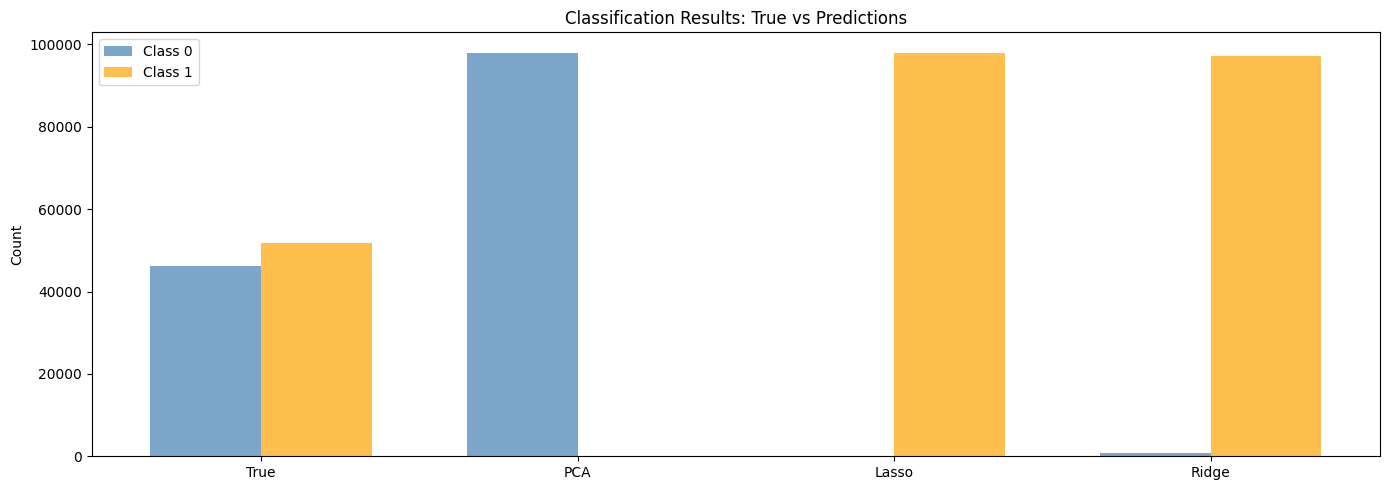

In [136]:
discrimination = predicted_dataset.T[0]

lasso_predict = best_lasso.predict(x_df.to_numpy())
ridge_predict = best_ridge.predict(x_df.to_numpy())


discrimination = (discrimination - min(discrimination))/(max(discrimination) - min(discrimination))
# lasso_predict = (lasso_predict - min(lasso_predict))/(max(lasso_predict) - min(lasso_predict))
ridge_predict = (ridge_predict - min(ridge_predict))/(max(ridge_predict) - min(ridge_predict))



true_dataset = y_df.to_numpy().astype(bool)

pca_prediction = discrimination > 0.5
lasso_prediction = lasso_predict > 0.5
ridge_prediction = ridge_predict > 0.5

print(pca_prediction)

plt.figure(figsize=(14, 5))

# Data preparation
class_0_counts = [np.sum(true_dataset.astype(int) == 0), np.sum(pca_prediction.astype(int) == 0), 
                  np.sum(lasso_prediction.astype(int) == 0), np.sum(ridge_prediction.astype(int) == 0)]
class_1_counts = [np.sum(true_dataset.astype(int) == 1), np.sum(pca_prediction.astype(int) == 1), 
                  np.sum(lasso_prediction.astype(int) == 1), np.sum(ridge_prediction.astype(int) == 1)]

x_pos = np.arange(4)  # 4 methods: True, PCA, Lasso, Ridge
width = 0.35

plt.bar(x_pos - width/2, class_0_counts, width, alpha=0.7, label='Class 0', color='steelblue')
plt.bar(x_pos + width/2, class_1_counts, width, alpha=0.7, label='Class 1', color='orange')

plt.xticks(x_pos, ['True', 'PCA', 'Lasso', 'Ridge'])
plt.ylabel('Count')
plt.title('Classification Results: True vs Predictions')
plt.legend()
plt.tight_layout()
plt.show()
